In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from ucimlrepo import fetch_ucirepo
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [3]:
print("Loading Online Retail II...")
df_raw = pd.read_csv(
    "../data/raw/online_retail_II.csv",
    encoding="utf-8",
    dtype={"Customer ID": str}
)

print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(df_raw.head())

Loading Online Retail II...
Raw shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price Customer ID         Country  
0  2009-12-01 07:45:00   6.95     13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75     13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75     13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10     13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25     13085.0  United Kingdom  


In [4]:
df = df_raw.copy()

# Remove cancellations (Invoice starts with C)
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Keep only UK (largest market, most complete data)
df = df[df["Country"] == "United Kingdom"]

# Remove bad rows
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df = df.dropna(subset=["Customer ID", "Description"])

# Remove noise stock codes
noise_codes = ["POST","DOT","M","BANK CHARGES","PADS","D","C2"]
df = df[~df["StockCode"].isin(noise_codes)]

print(f"Clean shape : {df.shape}")
print(f"Invoices    : {df['Invoice'].nunique():,}")
print(f"Products    : {df['Description'].nunique():,}")
print(f"Customers   : {df['Customer ID'].nunique():,}")

Clean shape : (724465, 8)
Invoices    : 33,384
Products    : 5,241
Customers   : 5,336


In [5]:
# Use top 100 products only — full 5,241 products makes matrix too large
top_products = (df.groupby("Description")["Quantity"]
                  .sum()
                  .nlargest(100)
                  .index.tolist())

df_top = df[df["Description"].isin(top_products)]

# Build basket: one row per invoice, one column per product
# Value = True if product appears in that invoice
basket = (df_top.groupby(["Invoice", "Description"])["Quantity"]
                .sum()
                .unstack()
                .fillna(0)
                .astype(bool))

print(f"Basket matrix shape: {basket.shape}")
print(f"Rows = invoices, Columns = products")
print(f"Density: {basket.values.sum() / basket.size * 100:.2f}%")

Basket matrix shape: (25454, 100)
Rows = invoices, Columns = products
Density: 3.87%


In [6]:
# FP-Growth algorithm — faster than Apriori for large datasets
print("Running FP-Growth...")
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.02,      # product pair must appear in at least 2% of invoices
    use_colnames=True,
    max_len=3              # max 3 items per itemset
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

print(f"Frequent itemsets found: {len(frequent_itemsets):,}")
print(f"\nBreakdown by length:")
print(frequent_itemsets["length"].value_counts().sort_index())
print(f"\nTop 10 most frequent single items:")
print(frequent_itemsets[frequent_itemsets["length"]==1]
      .nlargest(10, "support")[["itemsets","support"]]
      .to_string(index=False))

Running FP-Growth...
Frequent itemsets found: 106

Breakdown by length:
length
1    75
2    31
Name: count, dtype: int64

Top 10 most frequent single items:
                                       itemsets  support
frozenset({WHITE HANGING HEART T-LIGHT HOLDER}) 0.184686
          frozenset({REGENCY CAKESTAND 3 TIER}) 0.112202
     frozenset({ASSORTED COLOUR BIRD ORNAMENT}) 0.098374
           frozenset({JUMBO BAG RED RETROSPOT}) 0.093934
                     frozenset({PARTY BUNTING}) 0.076255
           frozenset({LUNCH BAG  BLACK SKULL.}) 0.074723
             frozenset({HEART OF WICKER SMALL}) 0.067966
             frozenset({HEART OF WICKER LARGE}) 0.067612
       frozenset({WOODEN FRAME ANTIQUE WHITE }) 0.067534
        frozenset({LUNCH BAG SPACEBOY DESIGN }) 0.065962


In [7]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.5
)

# Clean up for display
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(list(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(list(x)))

rules = rules.sort_values("lift", ascending=False)

print(f"Association rules found: {len(rules)}")
print(f"\nTop 15 rules by lift:")
print(rules[["antecedents_str","consequents_str","support","confidence","lift"]]
      .head(15)
      .to_string(index=False))

Association rules found: 60

Top 15 rules by lift:
                   antecedents_str                    consequents_str  support  confidence      lift
  PINK BLUE FELT CRAFT TRINKET BOX PINK CREAM FELT CRAFT TRINKET BOX  0.021293    0.575983 12.488136
PINK CREAM FELT CRAFT TRINKET BOX    PINK BLUE FELT CRAFT TRINKET BOX 0.021293    0.461670 12.488136
VINTAGE HEADS AND TAILS CARD GAME                  VINTAGE SNAP CARDS 0.021765    0.591880 10.784339
                VINTAGE SNAP CARDS VINTAGE HEADS AND TAILS CARD GAME  0.021765    0.396564 10.784339
    STRAWBERRY CERAMIC TRINKET BOX     SWEETHEART CERAMIC TRINKET BOX 0.029701    0.456246 10.586410
    SWEETHEART CERAMIC TRINKET BOX     STRAWBERRY CERAMIC TRINKET BOX 0.029701    0.689152 10.586410
        COOK WITH WINE METAL SIGN         GIN + TONIC DIET METAL SIGN 0.021647    0.479965  9.144486
       GIN + TONIC DIET METAL SIGN         COOK WITH WINE METAL SIGN  0.021647    0.412425  9.144486
 WOODEN PICTURE FRAME WHITE FINISH      

D:\All Project\E_Commerce_Project\japan-ecommerce-analytics\.venv\Lib\site-packages\kaleido\scopes\plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
D:\All Project\E_Commerce_Project\japan-ecommerce-analytics\.venv\Lib\site-packages\kaleido\scopes\plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
D:\All Project\E_Commerce_Project\japan-ecommerce-analytics\.venv\Lib\site-packages\kaleido\scopes\plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
D:\All Project\E_Com

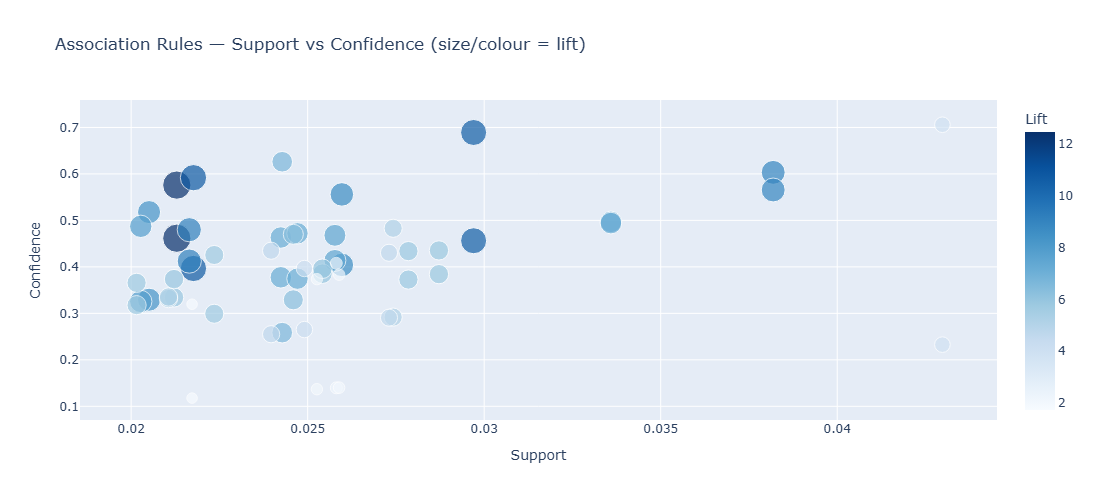

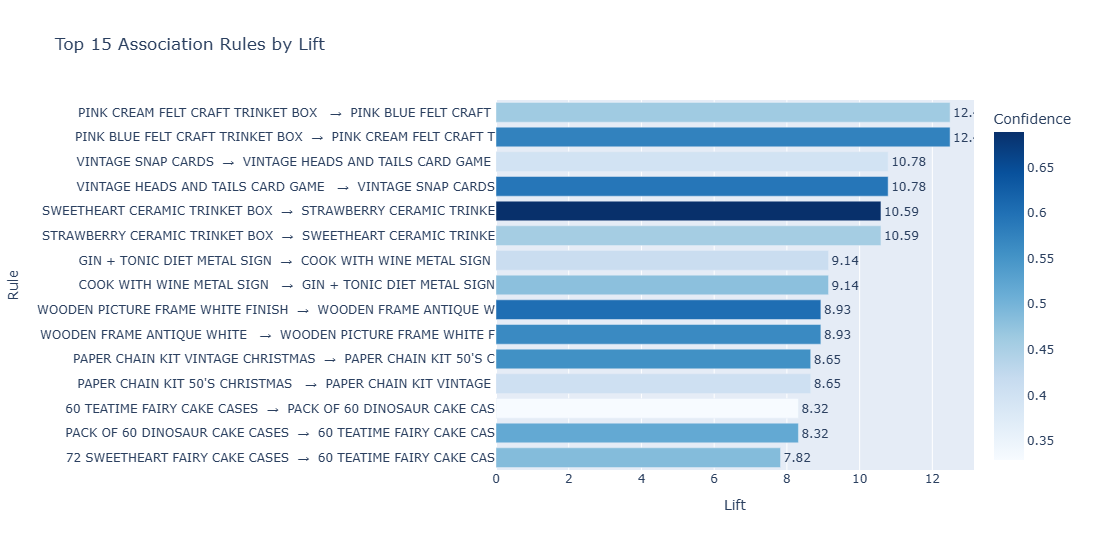

In [9]:
# Chart 1: Scatter — support vs confidence coloured by lift
fig1 = px.scatter(
    rules,
    x="support",
    y="confidence",
    color="lift",
    size="lift",
    hover_data=["antecedents_str", "consequents_str"],
    color_continuous_scale="Blues",
    title="Association Rules — Support vs Confidence (size/colour = lift)",
    labels={"support": "Support", "confidence": "Confidence", "lift": "Lift"}
)
fig1.update_layout(height=500)
fig1.show()

# Chart 2: Top 15 rules by lift — horizontal bar
top_rules = rules.head(15).copy()
top_rules["rule"] = top_rules["antecedents_str"] + "  →  " + top_rules["consequents_str"]
top_rules["rule"] = top_rules["rule"].str[:60]  # truncate long labels

fig2 = px.bar(
    top_rules.sort_values("lift"),
    x="lift",
    y="rule",
    orientation="h",
    color="confidence",
    color_continuous_scale="Blues",
    text=top_rules.sort_values("lift")["lift"].round(2),
    title="Top 15 Association Rules by Lift",
    labels={"lift": "Lift", "rule": "Rule", "confidence": "Confidence"}
)
fig2.update_traces(textposition="outside")
fig2.update_layout(height=550, margin=dict(l=350))
fig2.show()

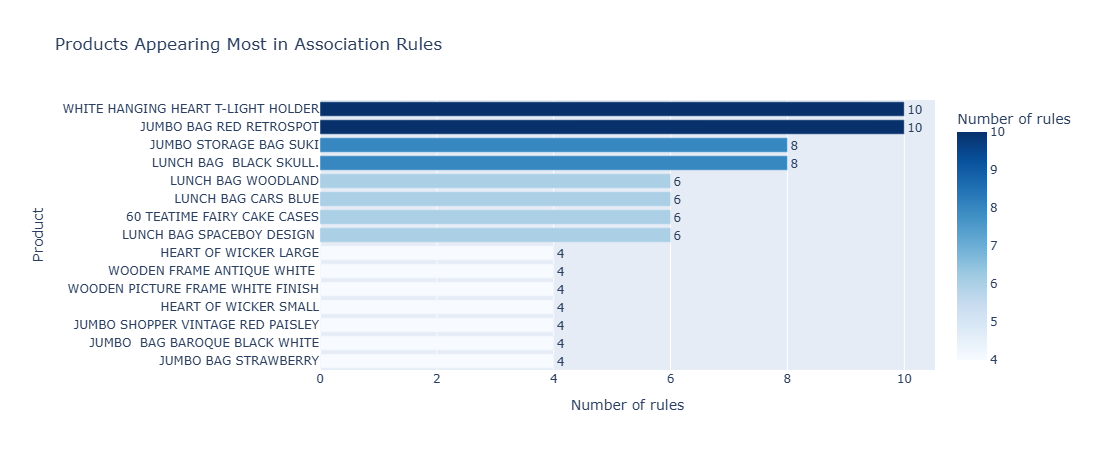

In [10]:
# Count how many rules each product appears in
from collections import Counter

all_products = (
    rules["antecedents_str"].tolist() +
    rules["consequents_str"].tolist()
)
product_counts = Counter(all_products)
product_df = pd.DataFrame(
    product_counts.items(),
    columns=["product", "rule_count"]
).sort_values("rule_count", ascending=False)

fig3 = px.bar(
    product_df.head(15).sort_values("rule_count"),
    x="rule_count",
    y="product",
    orientation="h",
    text="rule_count",
    title="Products Appearing Most in Association Rules",
    labels={"rule_count": "Number of rules", "product": "Product"},
    color="rule_count",
    color_continuous_scale="Blues"
)
fig3.update_traces(textposition="outside")
fig3.update_layout(height=450, margin=dict(l=320))
fig3.show()

In [ ]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/05_basket_scatter.html")
fig2.write_html("../docs/screenshots/05_basket_rules.html")
fig3.write_html("../docs/screenshots/05_basket_products.html")

rules[["antecedents_str","consequents_str","support","confidence","lift"]]\
    .to_csv("../data/processed/05_association_rules.csv", index=False)

print("MARKET BASKET ANALYSIS SUMMARY")
print(f"Dataset        : Online Retail II (UCI) — UK gift-ware")
print(f"Invoices       : 33,384")
print(f"Products used  : top 100 by volume")
print(f"Min support    : 2%")
print(f"Frequent sets  : {len(frequent_itemsets)}")
print(f"Rules found    : {len(rules)}")
print(f"Max lift       : {rules['lift'].max():.2f}")
print()
print("TOP 5 RULES:")
for _, row in rules.head(5).iterrows():
    print(f"  {row['antecedents_str']} → {row['consequents_str']}")
    print(f"  lift={row['lift']:.2f}, confidence={row['confidence']:.2f}")
    print()
print("FINDINGS:")
print("1. Trinket box variants are strongest pairs (lift=12.5)")
print("2. Vintage card games bought together frequently (lift=10.8)")
print("3. Wooden frames show strong cross-sell potential (lift=8.9)")
print("4. Seasonal items (paper chains, cake cases) cluster tightly")
print()
print("RECOMMENDATIONS:")
print("1. Bundle trinket box variants as gift sets")
print("2. Create 'frequently bought together' section on product pages")
print("3. Trigger email with consequent item after antecedent purchase")
print("4. Apply same analysis to Olist categories for Brazil market")